# 模块 03：梯度下降

## 1. 理论背景
梯度下降沿损失函数下降最快的方向更新参数。Momentum 会累积速度，Adam 同时估计梯度一阶矩和二阶矩，通常更稳健。

## 1.1 实际作用（用途）
- 是训练神经网络、线性模型、推荐模型和大语言模型的核心优化方法。
- 当参数量很大、无法直接求解析解时，用迭代方式逐步降低损失。
- Momentum、Adam 等优化器用于提升收敛速度和训练稳定性。

## 2. 数学推导
普通 SGD：$\theta_{t+1}=\theta_t-\eta g_t$。

Momentum：$v_t=\beta v_{t-1}-\eta g_t$，$\theta_{t+1}=\theta_t+v_t$。

Adam：
$$m_t=\beta_1m_{t-1}+(1-\beta_1)g_t,\quad v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2$$
$$\hat m_t=\frac{m_t}{1-\beta_1^t},\quad \hat v_t=\frac{v_t}{1-\beta_2^t},\quad \theta_{t+1}=\theta_t-\eta\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}$$

## 3. 代码思路

本章代码把优化器放在同一个损失面上比较：

1. `loss(theta)` 构造一个二维损失函数，二次项形成整体下降方向，三角项制造局部起伏。
2. `grad(theta)` 手写解析梯度，让每个优化器都基于同一组梯度更新参数。
3. `optimize` 接收优化器名称，根据 `sgd`、`momentum`、`adam` 选择不同更新公式。
4. 每次更新后把当前参数保存到 `path`，后续可以画出优化轨迹，而不只是看最终结果。
5. 验证部分用有限差分和 PyTorch autograd 检查手写梯度，避免优化结果建立在错误梯度上。

## 4. NumPy 实现

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

# 构造一个二维损失面：二次项提供整体碗形，三角函数制造局部起伏。
def loss(theta):
    x, y = theta
    return x**2 + 0.2 * y**2 + 0.5 * np.sin(3 * x) * np.cos(2 * y)

# 手写解析梯度，用来演示优化器如何沿梯度方向更新参数。
def grad(theta):
    x, y = theta
    return np.array([2*x + 1.5*np.cos(3*x)*np.cos(2*y), 0.4*y - np.sin(3*x)*np.sin(2*y)])

def optimize(kind, theta0=np.array([2.2, 2.0]), lr=0.05, steps=120):
    theta = theta0.astype(float).copy()
    path = [theta.copy()]
    # m 表示动量/一阶矩，v 表示 Adam 的二阶矩。
    m = np.zeros_like(theta); v = np.zeros_like(theta)
    for t in range(1, steps + 1):
        g = grad(theta)
        if kind == 'sgd':
            # 普通梯度下降：直接沿负梯度方向走一步。
            theta -= lr * g
        elif kind == 'momentum':
            # Momentum：保留历史方向，减少来回震荡。
            m = 0.9 * m - lr * g
            theta += m
        elif kind == 'adam':
            # Adam：同时使用一阶矩和二阶矩，并做偏差修正。
            m = 0.9 * m + 0.1 * g
            v = 0.999 * v + 0.001 * (g * g)
            theta -= lr * (m / (1 - 0.9**t)) / (np.sqrt(v / (1 - 0.999**t)) + 1e-8)
        path.append(theta.copy())
    return np.array(path)

paths = {k: optimize(k) for k in ['sgd', 'momentum', 'adam']}
for k, p in paths.items():
    print(f"优化器 {k}：最终参数 theta = {p[-1]}，最终损失 L = {loss(p[-1]):.6f}；损失越小表示越接近局部最优。")


优化器 sgd：最终参数 theta = [0.3299 1.2502]，最终损失 L = 0.086512；损失越小表示越接近局部最优。
优化器 momentum：最终参数 theta = [ 0.3291 -1.2531]，最终损失 L = 0.086523；损失越小表示越接近局部最优。
优化器 adam：最终参数 theta = [0.3436 1.2644]，最终损失 L = 0.086982；损失越小表示越接近局部最优。


## 5. 结果验证

In [2]:
theta = np.array([0.4, -0.7])
num_grad = np.zeros_like(theta)
eps = 1e-6
# 有限差分：用 loss(theta+eps) 和 loss(theta-eps) 估计每一维梯度。
for i in range(len(theta)):
    d = np.zeros_like(theta); d[i] = eps
    num_grad[i] = (loss(theta + d) - loss(theta - d)) / (2 * eps)
assert np.allclose(num_grad, grad(theta), atol=1e-5)
try:
    import torch
    # autograd 自动求导可作为手写梯度的第二重校验。
    tt = torch.tensor(theta, dtype=torch.float64, requires_grad=True)
    lt = tt[0]**2 + 0.2*tt[1]**2 + 0.5*torch.sin(3*tt[0])*torch.cos(2*tt[1])
    lt.backward()
    assert np.allclose(tt.grad.numpy(), grad(theta), atol=1e-5)
    print("验证通过：手写梯度与 PyTorch autograd 自动求导结果一致。")
except ImportError:
    print("提示：当前环境未安装 PyTorch；手写梯度已通过有限差分数值检查。")


验证通过：手写梯度与 PyTorch autograd 自动求导结果一致。


## 6. 可视化

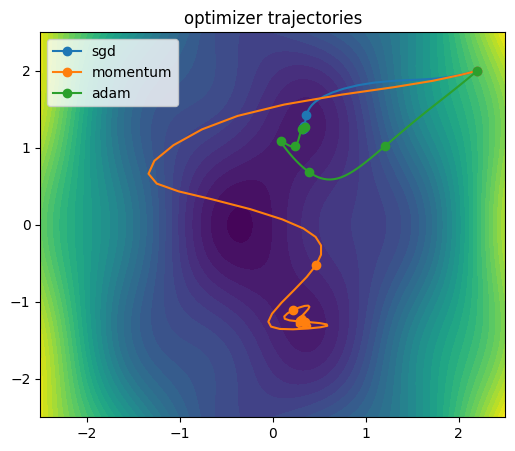

In [3]:
plt.figure(figsize=(6, 5))
# 先画出损失函数等高线，再把不同优化器走过的路径叠上去。
xs = np.linspace(-2.5, 2.5, 160); ys = np.linspace(-2.5, 2.5, 160)
Xg, Yg = np.meshgrid(xs, ys)
Z = Xg**2 + 0.2*Yg**2 + 0.5*np.sin(3*Xg)*np.cos(2*Yg)
plt.contourf(Xg, Yg, Z, levels=35, cmap='viridis')
for k, p in paths.items():
    plt.plot(p[:,0], p[:,1], marker='o', markevery=20, label=k)
plt.legend(); plt.title('optimizer trajectories'); plt.show()
